In [38]:
from datasets import WRsmallepoch
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, WeightedRandomSampler
from matplotlib import pyplot as plt

In [39]:


dataset = WRsmallepoch(
data_file = '/app/Data/WR/WR5_Run4.hdf5', 
annotation_file = '/app/Data/WR/Annotations/260218_annotations_a.pkl',
epoch_size=5,
epoch_id_restriction=None, 
sample_rate= 5000,
single_channel_flag=True,
psd_flag=True
)


datasampler = WeightedRandomSampler(weights=1/dataset.frequencies, num_samples=len(dataset), replacement=True)



In [40]:
dataloader = DataLoader(dataset,batch_size=500,sampler=datasampler)

d = iter(dataloader)

In [41]:
example, labels = next(d)
example = example.squeeze().numpy()


means = np.mean(example, axis=0)
stds = np.std(example, axis=0)
example_norm = (example - means) / (stds + 1e-6)


(array([160.,   0.,   0.,   0.,   0., 165.,   0.,   0.,   0., 175.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

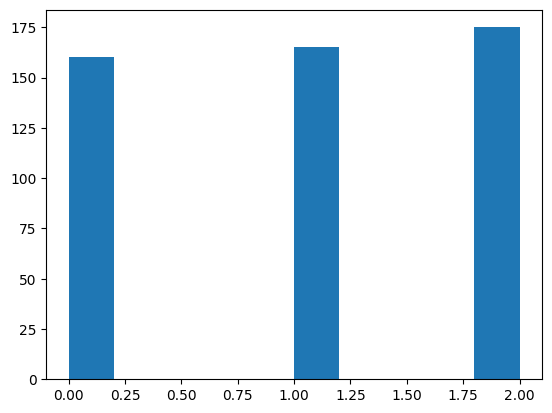

In [42]:
plt.hist(labels)

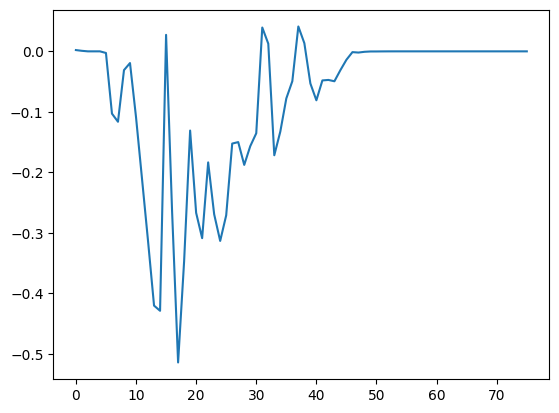

In [35]:
plt.plot(example_norm[4,:])

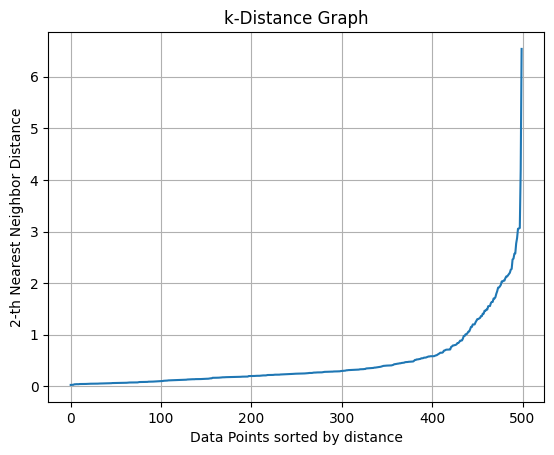

In [29]:
# Set the number of neighbors
k = 2  # For example, if min_samples is 5, set k to 4

# Compute the k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(out)
distances, indices = neighbors_fit.kneighbors(out)

# Sort the distances
distances = np.sort(distances[:, k-1], axis=0)

# Plot the k-distance graph
plt.plot(distances)
plt.title('k-Distance Graph')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{k}-th Nearest Neighbor Distance')
plt.grid(True)

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
out = pca.fit_transform(example_norm)
print(out.shape)

(500, 4)


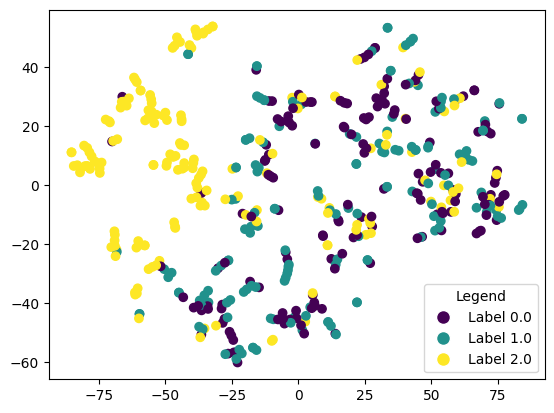

In [51]:
import numpy as np
from sklearn.manifold import TSNE
X = example_norm
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X)
X_embedded.shape

scatter = plt.scatter(X_embedded[:,0],X_embedded[:,1],c=labels, cmap='viridis')

# Create a custom legend
# Get the unique labels
unique_labels = np.unique(labels)

# Create legend handles
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Label {label}',
                             markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10)
                  for label in unique_labels]

# Add the legend to the plot
plt.legend(handles=legend_handles, title="Legend")